
# 💬 NLP Fundamentals — Colab Demos (Week 2 & 3)
This notebook contains compact **teaching demos** for core NLP topics in CENG442.  
**How to use:** Open in Google Colab, then run each section in order. Sections are self‑contained, so you can also run them individually.



## 0) Environment Setup (run once)
In Colab you may already have most libraries, but the cell below makes sure everything is present and downloads the small English model for spaCy plus the NLTK data used later.

**What are these packages?**
- **NLTK** (*Natural Language Toolkit*): a classic Python library for teaching/experimentation that ships with datasets and algorithms (tokenizers, taggers, etc.).
- **spaCy**: a modern, efficient NLP library with industrial‑strength tokenization, tagging and NER. We use the small English model `en_core_web_sm` for speed.
- **matplotlib**: plotting library (preinstalled in Colab).
- **NLTK data packages**:
  - `punkt`: sentence tokenizer data.
  - `stopwords`: curated lists of function words (e.g., *the, and*).
  - `wordnet`: lexicon for English; supports lemmatization.
  - `averaged_perceptron_tagger`: POS tagger model.
  - `maxent_ne_chunker` & `words`: resources for NLTK’s classic NER chunker.
  - `gutenberg`: sample literary texts used in teaching demos.


In [ ]:

!pip -q install nltk spacy

import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('words')
nltk.download('gutenberg')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

# Download spaCy's small English model
import sys, subprocess
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=False)

print("✅ Setup complete. Proceed to section 1.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


✅ Setup complete. Proceed to section 1.



## 1) Human Language vs. Programming Languages — Linguistic Ambiguity
Human languages are **ambiguous** and rely on **context**; programming languages are **strict** and unambiguous. The cell below shows a sentence with two valid interpretations and contrasts it with Python’s strict syntax.


In [ ]:

sentence = "I saw the man with the telescope."
interpretations = [
    "I used a telescope to see the man.",
    "I saw a man who was holding a telescope."
]
print("Sentence:", sentence)
print("Two valid interpretations:")
for i, s in enumerate(interpretations, 1):
    print(f"{i}. {s}")

print("\nNow try to run invalid Python:")
code = "for i in range(3) print(i)"
try:
    exec(code)
except SyntaxError as e:
    print("❌ SyntaxError demonstrates how strict programming languages are:", e)


Sentence: I saw the man with the telescope.
Two valid interpretations:
1. I used a telescope to see the man.
2. I saw a man who was holding a telescope.

Now try to run invalid Python:
❌ SyntaxError demonstrates how strict programming languages are: invalid syntax (<string>, line 1)



## 2) Tokenization (sentences & words)
**Goal:** split raw text into smaller units (sentences or tokens/words).  
**Why not `split()`?** `split()` simply breaks on whitespace, so it glues punctuation to words and mishandles abbreviations.

**Imports explained**
- `from nltk.tokenize import sent_tokenize, word_tokenize` brings NLTK’s sentence and word tokenizers:
  - `sent_tokenize` uses the **Punkt** tokenizer model.
  - `word_tokenize` defaults to a **Treebank**-style tokenizer that separates punctuation.


In [ ]:

from nltk.tokenize import sent_tokenize, word_tokenize

text = ("Alan Turing was an English mathematician, computer scientist, and cryptanalyst. "
        "He proposed the Turing test as a criterion for machine intelligence.")

print("— Naive split() —")
print(text.split()[:12])

print("\n— NLTK sentence tokenization —")
print(sent_tokenize(text))

print("\n— NLTK word tokenization —")
print(word_tokenize(text))


— Naive split() —
['Alan', 'Turing', 'was', 'an', 'English', 'mathematician,', 'computer', 'scientist,', 'and', 'cryptanalyst.', 'He', 'proposed']

— NLTK sentence tokenization —
['Alan Turing was an English mathematician, computer scientist, and cryptanalyst.', 'He proposed the Turing test as a criterion for machine intelligence.']

— NLTK word tokenization —
['Alan', 'Turing', 'was', 'an', 'English', 'mathematician', ',', 'computer', 'scientist', ',', 'and', 'cryptanalyst', '.', 'He', 'proposed', 'the', 'Turing', 'test', 'as', 'a', 'criterion', 'for', 'machine', 'intelligence', '.']



### Bonus: spaCy tokenization at a glance
`spacy.load("en_core_web_sm")` loads a small English pipeline (rules + statistical components). Iterating over `doc` yields tokens; each token knows if it's punctuation, alphabetic, etc.


In [ ]:

import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("Mr. Smith bought apple-flavored snacks in the U.S.A., e.g., in New York.")
[(t.text, t.is_punct, t.is_alpha) for t in doc]


[('Mr.', False, False),
 ('Smith', False, True),
 ('bought', False, True),
 ('apple', False, True),
 ('-', True, False),
 ('flavored', False, True),
 ('snacks', False, True),
 ('in', False, True),
 ('the', False, True),
 ('U.S.A.', False, False),
 (',', True, False),
 ('e.g.', False, False),
 (',', True, False),
 ('in', False, True),
 ('New', False, True),
 ('York', False, True),
 ('.', True, False)]


## 3) Stopwords & Token Frequencies
**Idea:** very common function words (e.g., *the, is, and*) may carry little semantic signal for some tasks. We often **filter** them before computing features.

**Imports explained**
- `from nltk.corpus import stopwords` loads curated stopword lists (we’ll use English).
- `from nltk.corpus import gutenberg` gives access to classic literary texts bundled with NLTK (e.g., Austen, Melville). This is **not** the whole Project Gutenberg; it’s a **small teaching subset** shipped with NLTK.
- `from nltk import FreqDist` computes frequency distributions of tokens (counts + helper methods).
- `import matplotlib.pyplot as plt` lets us make a simple bar chart of the top tokens **after** removing stopwords.


Most common (with stopwords): [('the', 5201), ('to', 5181), ('and', 4877), ('of', 4284), ('i', 3177), ('a', 3124), ('it', 2503), ('her', 2448), ('was', 2396), ('she', 2336)]
Most common (without stopwords): [('emma', 860), ('could', 836), ('would', 818), ('miss', 599), ('must', 566), ('harriet', 500), ('much', 484), ('said', 483), ('one', 447), ('weston', 437)]


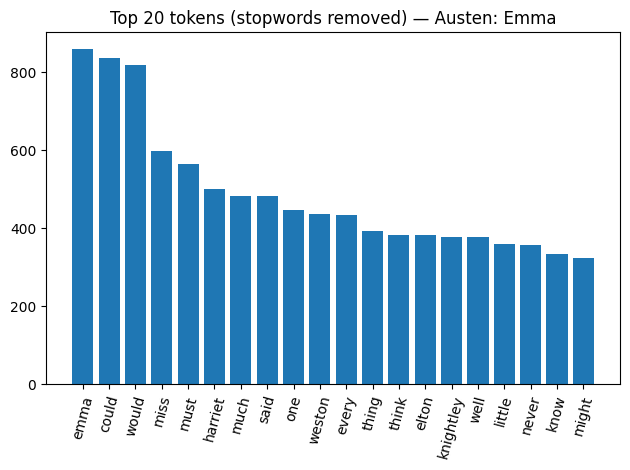

In [ ]:

from nltk.corpus import stopwords, gutenberg
from nltk import FreqDist
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt

# Sample book (Jane Austen’s "Emma")
raw = gutenberg.raw('austen-emma.txt')

# Basic normalization: lowercasing & keep only alphabetic tokens
tokens = [w.lower() for w in word_tokenize(raw) if w.isalpha()]

# With stopwords
freq_all = FreqDist(tokens)

# Without stopwords
stop_words = set(stopwords.words('english'))
tokens_nostop = [w for w in tokens if w not in stop_words]
freq_nostop = FreqDist(tokens_nostop)

print("Most common (with stopwords):", freq_all.most_common(10))
print("Most common (without stopwords):", freq_nostop.most_common(10))

# Plot top 20 without stopwords (one figure, default styling)
top_words, top_counts = zip(*freq_nostop.most_common(20))
plt.figure()
plt.bar(range(len(top_words)), top_counts)
plt.xticks(range(len(top_words)), top_words, rotation=75)
plt.title("Top 20 tokens (stopwords removed) — Austen: Emma")
plt.tight_layout()
plt.show()



## 4) Stemming (rule‑based suffix chopping)
**Goal:** reduce words to a common **stem** by stripping suffixes via heuristics. It’s fast but **coarse** (may over/under‑stem).

**Imports explained**
- `from nltk.stem import PorterStemmer` loads the classic **Porter (1980)** stemming algorithm.


In [ ]:

from nltk.stem import PorterStemmer

ps = PorterStemmer()
words = ["drive", "driving", "driver", "drivers", "drove", "drawing", "cats", "children"]
for w in words:
    print(f"{w:>10} -> {ps.stem(w)}")


     drive -> drive
   driving -> drive
    driver -> driver
   drivers -> driver
     drove -> drove
   drawing -> draw
      cats -> cat
  children -> children



## 5) Lemmatization (dictionary base forms)
**Goal:** return the **lemma** (dictionary form) using vocabulary + morphology. Usually more accurate than stemming, especially when we supply the **part‑of‑speech (POS)**.

**Imports explained**
- `from nltk.stem import WordNetLemmatizer`: lemmatizer backed by **WordNet**.
- `from nltk.corpus import wordnet`: defines POS constants and lemmas/synsets.


In [ ]:

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lem = WordNetLemmatizer()

print("driving (noun) ->", lem.lemmatize("driving", pos=wordnet.NOUN))
print("driving (verb) ->", lem.lemmatize("driving", pos=wordnet.VERB))
print("children ->", lem.lemmatize("children"))
print("cats ->", lem.lemmatize("cats"))
print("drove (verb) ->", lem.lemmatize("drove", pos=wordnet.VERB))


driving (noun) -> driving
driving (verb) -> drive
children -> child
cats -> cat
drove (verb) -> drive



## 6) Part‑of‑Speech (POS) Tagging
**Goal:** assign each token a grammatical tag (noun, verb, adjective, etc.). This helps downstream tasks (e.g., better lemmatization).

**Imports explained**
- `from nltk import pos_tag, word_tokenize`:
  - `pos_tag` uses NLTK’s default **Averaged Perceptron** model (we downloaded it as `averaged_perceptron_tagger`).
  - `word_tokenize` prepares tokens for tagging.
- `from nltk import help` to quickly display UPenn tagset descriptions.


In [ ]:

from nltk import pos_tag, word_tokenize, help

text = "Friedrich Nietzsche was a German philosopher and cultural critic."
tags = pos_tag(word_tokenize(text))
print(tags)

print("\nSome tag meanings:")


[('Friedrich', 'NNP'), ('Nietzsche', 'NNP'), ('was', 'VBD'), ('a', 'DT'), ('German', 'JJ'), ('philosopher', 'NN'), ('and', 'CC'), ('cultural', 'JJ'), ('critic', 'NN'), ('.', '.')]

Some tag meanings:


In [ ]:
"""
CC     coordinating conjunction
CD     cardinal digit
DT     determiner
EX     existential there (like: "there is" ... think of it like "there exists")
FW     foreign word
IN     preposition/subordinating conjunction
JJ     adjective 'big'
JJR    adjective, comparative 'bigger'
JJS    adjective, superlative 'biggest'
LS     list marker 1)
MD     modal could, will
NN     noun, singular 'desk'
NNS    noun plural 'desks'
NNP    proper noun, singular 'Harrison'
NNPS   proper noun, plural 'Americans'
PDT    predeterminer 'all the kids'
POS    possessive ending parent's
PRP    personal pronoun I, he, she
PRP$   possessive pronoun my, his, hers
RB     adverb very, silently,
RBR    adverb, comparative better
RBS    adverb, superlative best
RP     particle give up
TO     to go 'to' the store.
UH     interjection errrrrrrrm
VB     verb, base form take
VBD    verb, past tense took
VBG    verb, gerund/present participle taking
VBN    verb, past participle taken
VBP    verb, sing. present, non-3d take
VBZ    verb, 3rd person sing. present takes
WDT    wh-determiner which
WP     wh-pronoun who, what
WP$    possessive wh-pronoun whose
WRB    wh-abverb where, when
"""

'\nCC     coordinating conjunction\nCD     cardinal digit\nDT     determiner\nEX     existential there (like: "there is" ... think of it like "there exists")\nFW     foreign word\nIN     preposition/subordinating conjunction\nJJ     adjective \'big\'\nJJR    adjective, comparative \'bigger\'\nJJS    adjective, superlative \'biggest\'\nLS     list marker 1)\nMD     modal could, will\nNN     noun, singular \'desk\'\nNNS    noun plural \'desks\'\nNNP    proper noun, singular \'Harrison\'\nNNPS   proper noun, plural \'Americans\'\nPDT    predeterminer \'all the kids\'\nPOS    possessive ending parent\'s\nPRP    personal pronoun I, he, she\nPRP$   possessive pronoun my, his, hers\nRB     adverb very, silently,\nRBR    adverb, comparative better\nRBS    adverb, superlative best\nRP     particle give up\nTO     to go \'to\' the store.\nUH     interjection errrrrrrrm\nVB     verb, base form take\nVBD    verb, past tense took\nVBG    verb, gerund/present participle taking\nVBN    verb, past par


## 7) Named Entity Recognition (NER)
**Goal:** detect spans like **PERSON**, **ORGANIZATION**, **GPE** (countries/cities), **DATE**, etc.

**Two approaches**
- **NLTK `ne_chunk`** (classic): a maximum‑entropy chunker that relies on POS tags and the `maxent_ne_chunker` + `words` corpora. Simple and educational, but not state‑of‑the‑art.
- **spaCy** (modern): neural pipeline trained on annotated data; fast and practical for many applications.

**Imports explained**
- `from nltk import ne_chunk` and `pos_tag, word_tokenize` (for the NLTK pipeline).
- `import spacy` and `nlp = spacy.load("en_core_web_sm")` for spaCy’s small English model.


In [ ]:

# NER with NLTK (chunker)
from nltk import ne_chunk, pos_tag, word_tokenize

text = ("Steve Jobs was the co-founder and CEO of Apple Inc. "
        "He also led Pixar and founded NeXT in 1985 in the United States.")
tree = ne_chunk(pos_tag(word_tokenize(text)), binary=False)
print(tree)  # A tree structure with labels like PERSON, ORGANIZATION, GPE, DATE


(S
  (PERSON Steve/NNP)
  (PERSON Jobs/NNP)
  was/VBD
  the/DT
  co-founder/NN
  and/CC
  (ORGANIZATION CEO/NNP)
  of/IN
  (PERSON Apple/NNP Inc/NNP)
  ./.
  He/PRP
  also/RB
  led/VBD
  (PERSON Pixar/NNP)
  and/CC
  founded/VBD
  (ORGANIZATION NeXT/NNP)
  in/IN
  1985/CD
  in/IN
  the/DT
  (GPE United/NNP States/NNPS)
  ./.)


In [ ]:

# NER with spaCy (neural)
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("Barack Obama was born in Hawaii and served as the 44th President of the United States.")
[(ent.text, ent.label_) for ent in doc.ents]


[('Barack Obama', 'PERSON'),
 ('Hawaii', 'GPE'),
 ('44th', 'ORDINAL'),
 ('the United States', 'GPE')]


## 8) Working with a Corpus (NLTK Gutenberg)
**Terminology**
- **Token**: an instance of a word in text (includes repetitions).
- **Type** (vocabulary item): a unique word form.
- **Vocabulary size**: number of unique types.
- **Average sentence length**: rough proxy for writing style/complexity.

**Imports explained**
- `from nltk.corpus import gutenberg` provides access to small, built‑in literary texts (e.g., *Moby Dick*).
- `from collections import Counter` for simple frequency counts.


In [ ]:

from nltk.corpus import gutenberg
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter

raw = gutenberg.raw('melville-moby_dick.txt')
sents = sent_tokenize(raw)
words = [w.lower() for w in word_tokenize(raw) if w.isalpha()]
vocab = set(words)

avg_sent_len = sum(len(word_tokenize(s)) for s in sents) / len(sents)
print("Sentences:", len(sents))
print("Tokens:", len(words))
print("Vocab size (unique types):", len(vocab))
print("Average sentence length (tokens):", round(avg_sent_len, 2))
print("Top-20 words:", Counter(words).most_common(20))


Sentences: 9852
Tokens: 210512
Vocab size (unique types): 16519
Average sentence length (tokens): 25.91
Top-20 words: [('the', 14422), ('of', 6586), ('and', 6414), ('a', 4698), ('to', 4597), ('in', 4163), ('that', 3084), ('his', 2530), ('it', 2518), ('i', 2121), ('he', 1895), ('but', 1813), ('is', 1748), ('as', 1741), ('with', 1722), ('was', 1652), ('for', 1616), ('all', 1508), ('this', 1393), ('at', 1318)]
